In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Load CSV file
df = pd.read_csv('/Users/starrism/Desktop/243/code/coursera_full_2026.csv')
print("Dataset Shape:", df.shape)

Dataset Shape: (18500, 10)


### 1. Count missing values for each column (including NaN, None, empty strings, and 0)

In [82]:
missing_count = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    zero_count = ((df[col] == 0) | (df[col] == '0')).sum() if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'float64' else 0
    total_missing = null_count + zero_count
    missing_count.append({
        'Column': col,
        'Missing_Count': total_missing,
        'Missing_Percentage': round(total_missing / len(df) * 100, 2),
        'Null_Count': null_count,
        'Zero_Count': zero_count
    })

missing_stats = pd.DataFrame(missing_count)
missing_stats = missing_stats.sort_values('Missing_Count', ascending=False)

print("\n" + "="*80)
print("Missing Values Statistics (Including 0 as Missing)")
print("="*80 + "\n")
print(missing_stats.to_string(index=False))


Missing Values Statistics (Including 0 as Missing)

          Column  Missing_Count  Missing_Percentage  Null_Count  Zero_Count
    Review count          18500              100.00           0       18500
Difficulty_level          18500              100.00       18500           0
         Ratings          12421               67.14       12421           0
        Workload           7421               40.11        7421           0
          Skills              1                0.01           1           0
    Course title              0                0.00           0           0
    Organization              0                0.00           0           0
        Language              0                0.00           0           0
     Course_link              0                0.00           0           0
           Price              0                0.00           0           0


a) Review count and Difficulty level exhibit substantial missingness. Given their potential importance for course quality analysis, they were retained but excluded from EDA. They may be incorporated if additional data become available.

b) Ratings and Workload show high missing rates (≈67% and 40%). Due to the lack of reliable references for imputation, no filling was performed. Future inclusion will depend on data availability.

c) The Skills field contains only one missing record. The record was removed during data cleaning.

In [80]:
print("Before removing rows with missing Skills: "+f"{len(df)}")

# Remove rows where Skills is null or empty
df_cleaned = df.dropna(subset=['Skills'], how='any')
df_cleaned = df_cleaned[df_cleaned['Skills'].str.strip() != '']

print("After removing rows with missing Skills: "+f"{len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Before removing rows with missing Skills: 18500
After removing rows with missing Skills: 18499
Rows removed: 1


### 2. Workload Normalization
Every 10 hours of study time is treated as one week. Workload is categorized into: within 1 week, 2–4 weeks, 5–8 weeks, and more than 8 weeks.


In [133]:
# --- Multilingual time unit patterns ---
WEEK_WORDS  = r"(week|weeks|semanas?|semaines?|semaine|woche|wochen|недел[яиь]|недель|周|週|주|أسبوع|أسابيع)"
MONTH_WORDS = r"(month|months|mes|meses|monat|monate|месяц|месяца|месяцев|月|개월|شهر|أشهر)"

# Hour and minute expressions (Russian, German, Arabic, Chinese, Japanese, Korean, Turkish, Italian included)
HOUR_WORDS = r"(hour|hours|hr|hrs|h|hora|horas|heure|heures|stunde|stunden|час|часа|часов|小时|小時|時間|시간|saat|ore|ساع(?:ة|تين|تان|ات))"
MIN_WORDS  = r"(minute|minutes|min|mins|minuto|minutos|دقيق(?:ة|تين|تان|ات)|分钟|分|分間|분|minuti)"

# Multilingual expressions meaning "per week"
PER_WEEK_PAT = r"(\/\s*week|per\s*week|a\s*week|each\s*week|weekly|wöch(e|en|ig)?|pro\s*woche|par\s*semaine|por\s*semana|в\s*недел[юи]|еженедельно|주당|/주|毎週|每周|أسبوعياً|في\s*الأسبوع)"

# Range separators (including “to”, “à”, Japanese wave dash, etc.)
RANGE_SEP = r"(?:-|–|—|to|a|à|~|～|〜|－)"

# Small number word dictionary (English & French)
NUM_WORDS = {
    "one":1, "two":2, "three":3, "four":4, "five":5,
    "six":6, "seven":7, "eight":8, "nine":9, "ten":10,
    "une":1, "un":1, "deux":2, "trois":3, "quatre":4,
    "cinq":5, "six":6, "sept":7, "huit":8, "neuf":9, "dix":10,
}

def _normalize_text(t: str) -> str:

    t = t.lower().strip()

    # Normalize full-width digits and wave dashes
    t = t.replace("２", "2").replace("３", "3").replace("４", "4").replace("５", "5")
    t = t.replace("６", "6").replace("７", "7").replace("８", "8").replace("９", "9").replace("１", "1")
    t = t.replace("〜", "~").replace("～", "~")

    # Replace number words with digits
    for word, num in NUM_WORDS.items():
        t = re.sub(rf"\b{word}\b", str(num), t)

    # Simplify Arabic dual forms
    t = t.replace("ساعتين", "2 ساعة").replace("ساعتان", "2 ساعة")
    t = t.replace("أسبوعين", "2 أسبوع").replace("أسبوعان", "2 أسبوع")

    return t


def _avg(a, b):
    return (a + b) / 2.0


def _extract_number_or_range(t: str, unit_pattern: str):
    """
    Extract numeric value from text.

    Supports:
    - ranges: "x-y unit" → average value
    - single value: "x unit" → x

    Returns float or None.
    """

    # range first
    m = re.search(rf"(\d+(?:[.,]\d+)?)\s*{RANGE_SEP}\s*(\d+(?:[.,]\d+)?)\s*{unit_pattern}", t)
    if m:
        a = float(m.group(1).replace(",", "."))
        b = float(m.group(2).replace(",", "."))
        return _avg(a, b)

    # single value
    m = re.search(rf"(\d+(?:[.,]\d+)?)\s*{unit_pattern}", t)
    if m:
        return float(m.group(1).replace(",", "."))
    return None


def extract_weeks(workload_text):
    """
    Parse workload text and estimate total duration in weeks.

    Priority:
    1) Explicit total weeks/months
    2) Sentence patterns (e.g., "for X weeks", "X-wöchig", "X недели", "X주")
    3) Total hours/minutes → hours / 10 = weeks
    4) If only hours/week is given without duration → cannot estimate → NaN
    """

    if pd.isna(workload_text):
        return np.nan

    t = _normalize_text(str(workload_text))

    if not t:
        return np.nan

    # 1. Detect weeks/months directly
    weeks = _extract_number_or_range(t, WEEK_WORDS)
    if weeks is not None:
        return weeks

    months = _extract_number_or_range(t, MONTH_WORDS)
    if months is not None:
        return months * 4.0  # 1 month ≈ 4 weeks

    # 2. Sentence-based duration detection
    m = re.search(rf"(?:for|over)\s*(\d+(?:[.,]\d+)?)\s*{WEEK_WORDS}", t)
    if m:
        return float(m.group(1).replace(",", "."))

    m = re.search(rf"(?:pendant|pour)\s*(\d+(?:[.,]\d+)?)\s*{WEEK_WORDS}", t)
    if m:
        return float(m.group(1).replace(",", "."))

    m = re.search(rf"(?:per|durante)\s*(\d+(?:[.,]\d+)?)\s*(settimana|settimane)", t)
    if m:
        return float(m.group(1).replace(",", "."))

    # German compact forms
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*[- ]?\s*wöch", t)
    if m:
        return float(m.group(1).replace(",", "."))

    m = re.search(r"(\d+(?:[.,]\d+)?)\s*(?:kurs)?wochen", t)
    if m:
        return float(m.group(1).replace(",", "."))

    # Russian
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*недел", t)
    if m:
        return float(m.group(1).replace(",", "."))

    # Korean
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*주", t)
    if m:
        return float(m.group(1).replace(",", "."))

    # Arabic
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*أسبوع|(\d+(?:[.,]\d+)?)\s*أسابيع", t)
    if m:
        num = m.group(1) or m.group(2)
        return float(num.replace(",", "."))

    # "less than two weeks"
    m = re.search(rf"less\s+than\s+(\d+(?:[.,]\d+)?)\s*{WEEK_WORDS}", t)
    if m:
        return float(m.group(1).replace(",", ".")) * 0.8

    # 3. Convert total time to weeks
    total_hours = 0.0

    h = _extract_number_or_range(t, HOUR_WORDS)
    if h is not None:
        total_hours += h

    m = _extract_number_or_range(t, MIN_WORDS)
    if m is not None:
        total_hours += m / 60.0

    # numeric fallback
    if total_hours == 0.0:
        only_num = re.fullmatch(r"\s*(\d+(?:[.,]\d+)?)\s*", t)
        if only_num:
            v = float(only_num.group(1).replace(",", "."))
            if v <= 40:
                total_hours = v
            elif v <= 600:
                total_hours = v / 60.0

    if total_hours > 0:
        return total_hours / 10.0  # 10 hours ≈ 1 week

    # 4. Only weekly hours without duration → cannot estimate
    if re.search(PER_WEEK_PAT, t):
        return np.nan

    return np.nan


def categorize_weeks(w):
    if pd.isna(w):
        return "Unrecognized"
    if w < 1:
        return "Within 1 week"
    elif w < 4:
        return "1–4 weeks"
    elif w <= 8:
        return "4–8 weeks"
    else:
        return "More than 8 weeks"


df_cleaned["estimated_weeks"] = df_cleaned["Workload"].apply(extract_weeks)
df_cleaned["workload_category"] = df_cleaned["estimated_weeks"].apply(categorize_weeks)
df_cleaned["workload_category"].value_counts()

workload_category
Unrecognized         7491
Within 1 week        4870
4–8 weeks            3977
1–4 weeks            2038
More than 8 weeks     123
Name: count, dtype: int64

### 3. Visualization


a) Top 20 Skills

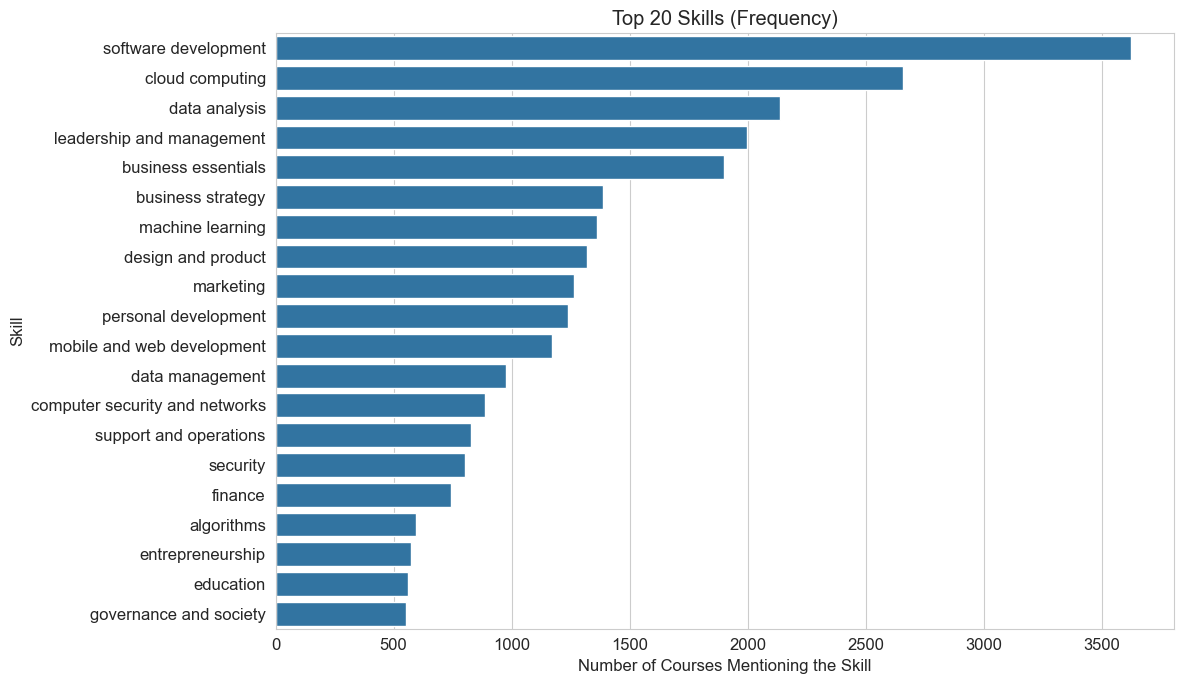

In [130]:
def parse_skills_cell(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    # Try Python list-like string
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i).strip().lower() for i in v if str(i).strip()]
    except Exception:
        pass
    # Fallback: split by common separators
    parts = re.split(r"[;,/|\n]+", s)
    return [p.strip().lower() for p in parts if p.strip()]

if "Skills" in df_cleaned.columns:
    skill_counter = Counter()

    for cell in df_cleaned["Skills"]:
        for sk in parse_skills_cell(cell):
            skill_counter[sk] += 1

    top_n = 20
    top_items = skill_counter.most_common(top_n)

    if len(top_items) > 0:
        skills, freqs = zip(*top_items)
        plt.figure(figsize=(12, 7))
        sns.barplot(y=list(skills), x=list(freqs))
        plt.title(f"Top {top_n} Skills (Frequency)")
        plt.xlabel("Number of Courses Mentioning the Skill")
        plt.ylabel("Skill")
        plt.tight_layout()
        plt.show()
    else:
        print("No skills parsed. Please check the 'Skills' column format.")
else:
    print("Column 'Skills' not found.")


b) Ratings histogram with mean & median

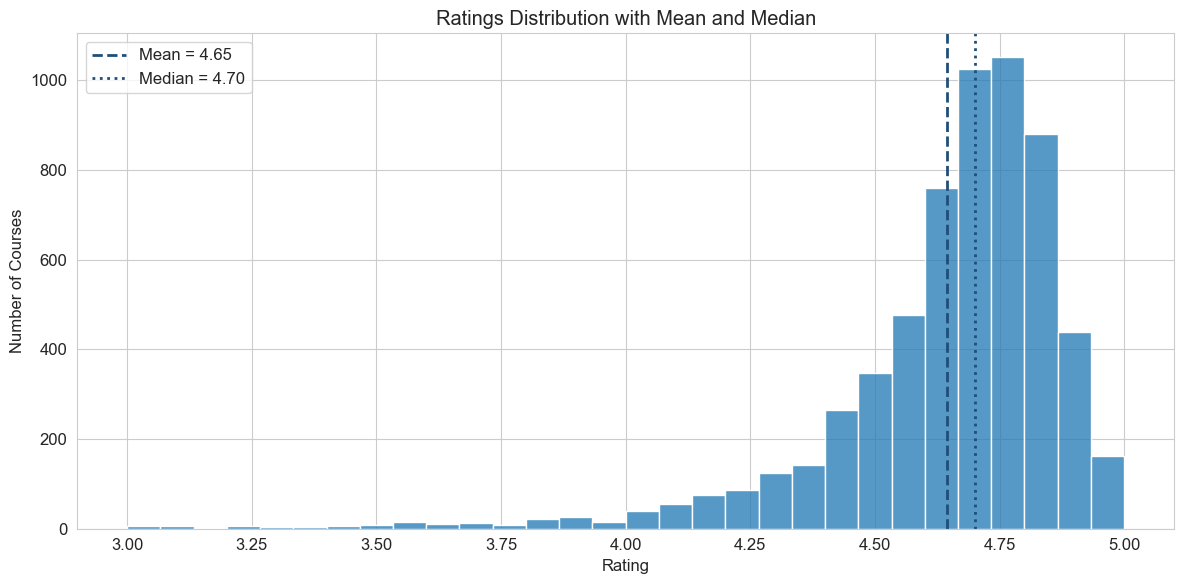

In [131]:
# Ratings histogram with mean/median reference lines
ratings = df_cleaned["Ratings"].dropna()

mean_val = ratings.mean()
median_val = ratings.median()

plt.figure(figsize=(12, 6))
sns.histplot(ratings, bins=30)
plt.title("Ratings Distribution with Mean and Median")
plt.xlabel("Rating")
plt.ylabel("Number of Courses")

plt.axvline(mean_val, color='#1F4E79', linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='#1F4E79', linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

plt.legend()
plt.tight_layout()
plt.show()


c) Top 20 Organizations by Course Count with Average Rating

Top 20 Organizations Statistics:

Rank  Organization                                  Courses    Avg Rating     
----------------------------------------------------------------------------------------------------
1     Coursera                                      2691       4.54           
2     Google Cloud                                  1656       4.59           
3     Packt                                         1438       4.56           
4     EDUCBA                                        786        4.72           
5     University of Colorado Boulder                415        4.59           
6     Google                                        374        4.80           
7     University of Michigan                        325        4.70           
8     Johns Hopkins University                      321        4.65           
9     University of Illinois Urbana-Champaign       280        4.64           
10    Microsoft                                     276        4.58        

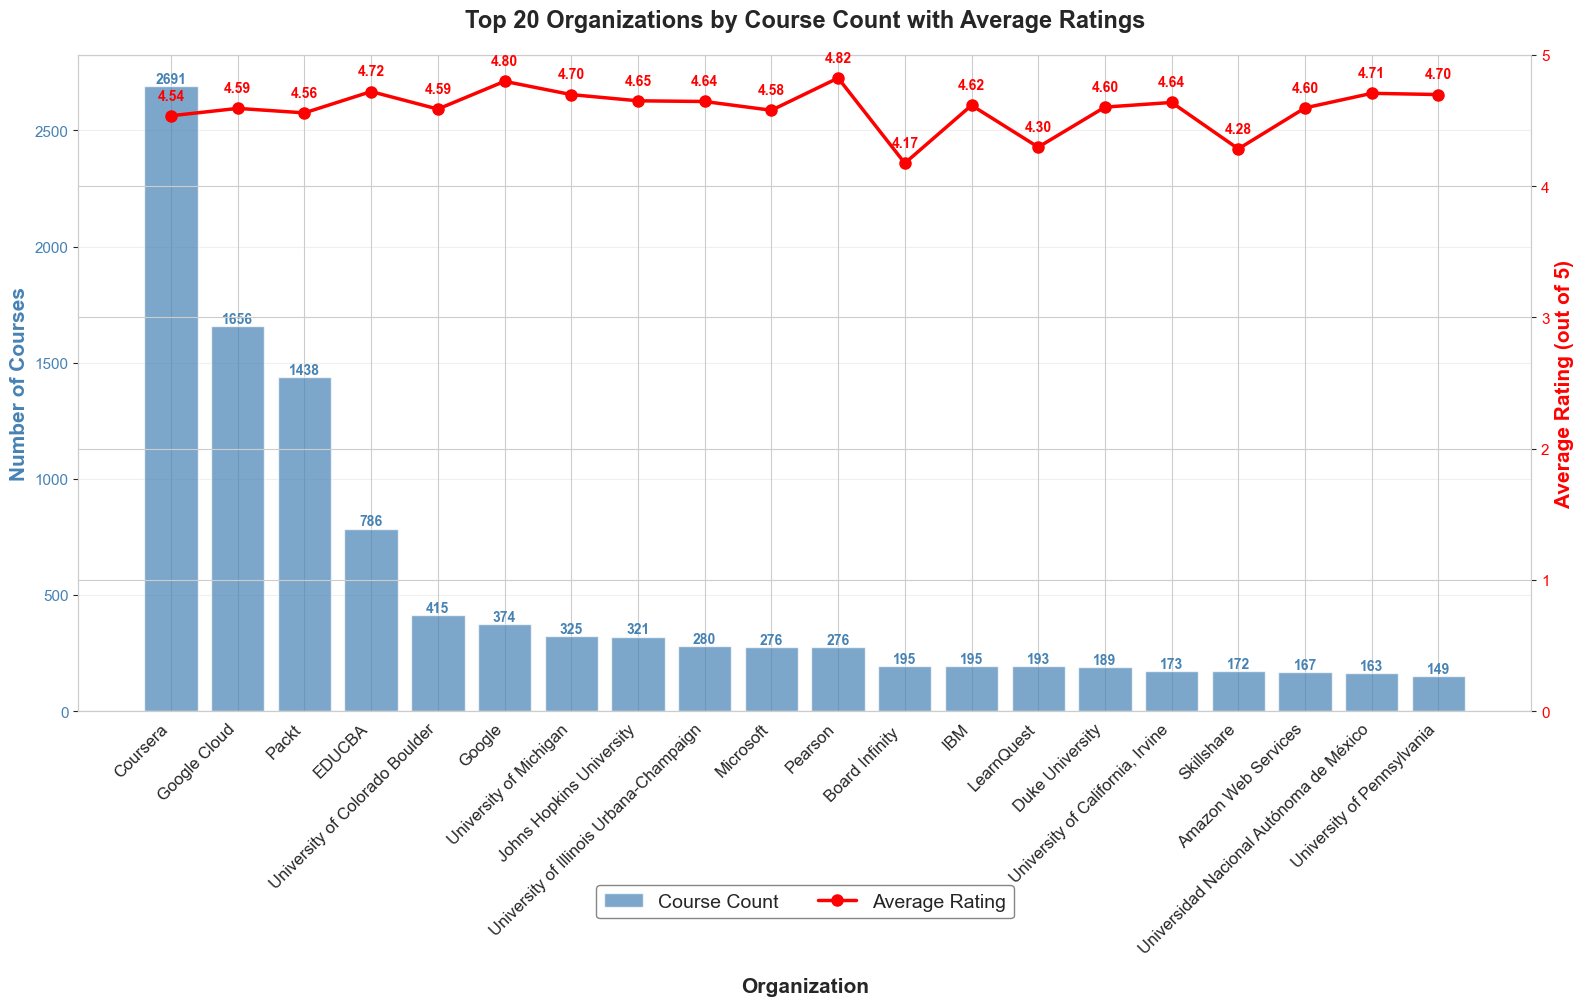


Summary Statistics:

Average Ratings (for 20 orgs with ratings):
  Mean rating: 4.59
  Median rating: 4.61
  Min rating: 4.17
  Max rating: 4.82


In [132]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['font.size'] = 12

# Get organization statistics
org_stats = df_cleaned.groupby('Organization').agg({
    'Course title': 'count',  # Number of courses
    'Ratings': lambda x: x.dropna().mean()  # Average ratings (excluding NaN)
}).rename(columns={'Course title': 'Course_Count', 'Ratings': 'Avg_Rating'})

# Get top 20 organizations by course count
top_20_orgs = org_stats.nlargest(20, 'Course_Count')

print("Top 20 Organizations Statistics:")
print("="*100)
print(f"\n{'Rank':<5} {'Organization':<45} {'Courses':<10} {'Avg Rating':<15}")
print("-"*100)

for rank, (org, row) in enumerate(top_20_orgs.iterrows(), 1):
    courses = int(row['Course_Count'])
    avg_rating = row['Avg_Rating']
    rating_str = f"{avg_rating:.2f}" if pd.notna(avg_rating) else "N/A"
    print(f"{rank:<5} {org:<45} {courses:<10} {rating_str:<15}")

# Create visualization
fig, ax = plt.subplots(figsize=(16, 9))

# Prepare data
x_pos = range(len(top_20_orgs))
course_counts = top_20_orgs['Course_Count'].values
avg_ratings = top_20_orgs['Avg_Rating'].values
orgs = top_20_orgs.index

# Create bar plot for course counts
bars = ax.bar(x_pos, course_counts, color='steelblue', alpha=0.7, label='Course Count')

# Add secondary y-axis for ratings
ax2 = ax.twinx()
line = ax2.plot(x_pos, avg_ratings, color='red', marker='o', linewidth=2.5, 
                markersize=8, label='Average Rating', linestyle='-')

# Customize primary axis (course count)
ax.set_xlabel('Organization', fontsize=15, fontweight='bold', labelpad=15)
ax.set_ylabel('Number of Courses', fontsize=15, fontweight='bold', color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(orgs, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelcolor='steelblue', labelsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Customize secondary axis (average rating)
ax2.set_ylabel('Average Rating (out of 5)', fontsize=15, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=11)
ax2.set_ylim([0, 5])

# Add value labels on bars
for i, (bar, rating) in enumerate(zip(bars, avg_ratings)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='steelblue')
    
    if pd.notna(rating):
        ax2.text(i, rating + 0.1, f'{rating:.2f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

# Title and legend
plt.title('Top 20 Organizations by Course Count with Average Ratings', 
          fontsize=17, fontweight='bold', pad=20)

# Combine legends - place at bottom center, outside plot area
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, 
         loc='upper center', bbox_to_anchor=(0.5, -0.25),
         fontsize=14, framealpha=0.95, edgecolor='gray', ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Extra space for legend
plt.show()

print("\n" + "="*100)
print("Summary Statistics:")
print("="*100)

# Rating statistics (excluding NaN)
valid_ratings = top_20_orgs['Avg_Rating'].dropna()
if len(valid_ratings) > 0:
    print(f"\nAverage Ratings (for {len(valid_ratings)} orgs with ratings):")
    print(f"  Mean rating: {valid_ratings.mean():.2f}")
    print(f"  Median rating: {valid_ratings.median():.2f}")
    print(f"  Min rating: {valid_ratings.min():.2f}")
    print(f"  Max rating: {valid_ratings.max():.2f}")
    
    orgs_without_rating = len(top_20_orgs) - len(valid_ratings)
    if orgs_without_rating > 0:
        print(f"\n  Orgs without rating data: {orgs_without_rating}")
